In [1]:
!pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5

In [1]:
# Clearing the environment

try:
    del full_dataset, train_indices, val_indices, train_subset, val_subset, train_loader, val_loader, labels, class_names, model, criterion, optimizer
except NameError:
    print("Some are non-existent!")

!rm -rf /kaggle/working/*
%reset -f


import gc

def reset_memory():
    # Delete all variables.
    for var in gc.get_objects():
        try:
            del var
        except:
            pass

    # Run the garbage collector.
    gc.collect()

    print("Memory has been reset")

# Call the function to reset memory

reset_memory()

Some are non-existent!
Memory has been reset


In [2]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # List and sort files
        self.image_files = sorted(os.listdir(img_dir))
        self.mask_files = sorted(os.listdir(mask_dir))

        assert len(self.image_files) == len(self.mask_files), \
            f"Mismatch: {len(self.image_files)} images vs {len(self.mask_files)} masks"

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        # Load image and mask
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale mask

        # Apply transforms (for image only)
        if self.transform is not None:
            image = self.transform(image)

        # Process mask (resize the same as transform resize)
        mask = transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.BILINEAR)(mask)
        mask = transforms.ToTensor()(mask)  # [0,1] float tensor
        mask = (mask > 0.5).long().squeeze(0)  # binarize & convert to long

        return image, mask

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.model_selection import train_test_split
import timm
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data transforms
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_img_dir = "/kaggle/input/mrose-data/split data/train images/"
train_mask_dir = "/kaggle/input/mrose-data/split data/train masks/"
val_img_dir = "/kaggle/input/mrose-data/split data/test images/"
val_mask_dir = "/kaggle/input/mrose-data/split data/test masks/"

train_dataset = SegmentationDataset(train_img_dir, train_mask_dir, transform=transform)
val_dataset = SegmentationDataset(val_img_dir, val_mask_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4)

In [5]:
!rm -rf /kaggle/working/*

In [4]:
!git clone https://github.com/shasan7/Enhanced_Architectures.git

Cloning into 'Enhanced_Architectures'...
remote: Enumerating objects: 323, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 323 (delta 57), reused 0 (delta 0), pack-reused 211 (from 1)
Receiving objects: 100% (323/323), 279.36 KiB | 9.01 MiB/s, done.
Resolving deltas: 100% (140/140), done.


In [5]:
from Enhanced_Architectures.Torchvision.uformer_max import MaxVit
model = MaxVit(input_size = (256, 256), num_classes=2, stem_channels=32, block_channels=[64, 128, 256, 512], block_layers=[2, 2, 2, 2], head_dim=32, stochastic_depth_prob=0.2, partition_size=8)
model = model.to(device)

print(f"Total Parameters = {sum(p.numel() for p in model.parameters())/1e6} M")
print(f"Trainable Parameters = {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6} M")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4, betas = (0.9, 0.999), weight_decay = 0.01)

Total Parameters = 28.179664 M
Trainable Parameters = 28.179664 M


In [6]:
import torch

def compute_segmentation_metrics(preds, targets, num_classes=2, smooth=1e-6):
    """
    preds, targets: (N, H, W) with integer labels in [0..num_classes-1]
    Returns dict of metrics similar to Hugging Face evaluate.
    """

    metrics = {}

    # === Dice & Dice Loss ===
    intersection = ((preds == 1) & (targets == 1)).sum().item()
    union = (preds == 1).sum().item() + (targets == 1).sum().item()
    dice = (2.0 * intersection + smooth) / (union + smooth)
    metrics["dice"] = dice
    metrics["dice_loss"] = 1 - dice

    # === Per-class IoU ===
    ious = []
    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)
        intersection = (pred_cls & target_cls).sum().item()
        union = (pred_cls | target_cls).sum().item()
        iou = (intersection + smooth) / (union + smooth)
        ious.append(iou)
        metrics[f"iou_class_{cls}"] = iou
    metrics["mean_iou"] = sum(ious) / num_classes
    metrics["iou_loss"] = 1 - metrics["mean_iou"]

    # === Per-class precision ===
    precisions = []
    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)
        tp = (pred_cls & target_cls).sum().item()
        fp = (pred_cls & ~target_cls).sum().item()
        precision = (tp + smooth) / (tp + fp + smooth)
        precisions.append(precision)
        metrics[f"precision_class_{cls}"] = precision
    metrics["mean_precision"] = sum(precisions) / num_classes

    # === Per-class accuracy ===
    accuracies = []
    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)
        correct = (pred_cls == target_cls).sum().item()
        total = target_cls.numel()
        acc = correct / total
        accuracies.append(acc)
        metrics[f"accuracy_class_{cls}"] = acc
    metrics["mean_accuracy"] = sum(accuracies) / num_classes

    # === mAP (for binary = mean of precisions) ===
    metrics["mAP"] = metrics["mean_precision"]

    return metrics

In [7]:
train_losses, val_losses = [], []
train_history, val_history = [], []  # store dict of metrics

best_val_dice = 0.0
best_model_path = "best_seg_model.pth"

epochs = 50
for epoch in range(epochs):
    # === Training ===
    model.train()
    running_loss = 0
    batch_metrics_list = []

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)  # masks: (N,H,W)

        outputs = model(images)  # (N,C,H,W)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Predictions
        if outputs.shape[1] > 1:  # multi-class
            preds = torch.argmax(outputs, dim=1)
        else:  # binary
            preds = (torch.sigmoid(outputs) > 0.5).long().squeeze(1)

        # Metrics for this batch
        batch_metrics = compute_segmentation_metrics(preds.cpu(), masks.cpu(), num_classes=2)
        batch_metrics_list.append(batch_metrics)

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Average metrics across epoch
    train_metrics = {k: sum(m[k] for m in batch_metrics_list) / len(batch_metrics_list)
                     for k in batch_metrics_list[0].keys()}
    train_history.append(train_metrics)

    # === Validation ===
    model.eval()
    val_loss = 0
    batch_metrics_list = []

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            if outputs.shape[1] > 1:
                preds = torch.argmax(outputs, dim=1)
            else:
                preds = (torch.sigmoid(outputs) > 0.5).long().squeeze(1)

            batch_metrics = compute_segmentation_metrics(preds.cpu(), masks.cpu(), num_classes=2)
            batch_metrics_list.append(batch_metrics)

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    val_metrics = {k: sum(m[k] for m in batch_metrics_list) / len(batch_metrics_list)
                   for k in batch_metrics_list[0].keys()}
    val_history.append(val_metrics)

    # === Logging ===
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} || "
          f"Dice: {val_metrics['dice']:.4f}, Dice Loss: {val_metrics['dice_loss']:.4f} | "
          f"IoU0: {val_metrics['iou_class_0']:.4f}, IoU1: {val_metrics['iou_class_1']:.4f}, Mean IoU: {val_metrics['mean_iou']:.4f} | "
          f"IoU Loss: {val_metrics['iou_loss']:.4f} | "
          f"Prec0: {val_metrics['precision_class_0']:.4f}, Prec1: {val_metrics['precision_class_1']:.4f}, mAP: {val_metrics['mAP']:.4f} | "
          f"Acc0: {val_metrics['accuracy_class_0']:.4f}, Acc1: {val_metrics['accuracy_class_1']:.4f}, Mean Acc: {val_metrics['mean_accuracy']:.4f}")

    # Save best model based on Dice
    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), best_model_path)
        print(f" Saved new best model with Dice: {best_val_dice:.4f}")

Epoch [1/50] | Train Loss: 0.0922, Val Loss: 0.0175 || Dice: 0.6000, Dice Loss: 0.4000 | IoU0: 0.9962, IoU1: 0.4488, Mean IoU: 0.7225 | IoU Loss: 0.2775 | Prec0: 0.9968, Prec1: 0.8416, mAP: 0.9192 | Acc0: 0.9962, Acc1: 0.9962, Mean Acc: 0.9962
 Saved new best model with Dice: 0.6000
Epoch [2/50] | Train Loss: 0.0156, Val Loss: 0.0147 || Dice: 0.3732, Dice Loss: 0.6268 | IoU0: 0.9952, IoU1: 0.2534, Mean IoU: 0.6243 | IoU Loss: 0.3757 | Prec0: 0.9952, Prec1: 0.9799, mAP: 0.9876 | Acc0: 0.9952, Acc1: 0.9952, Mean Acc: 0.9952
Epoch [3/50] | Train Loss: 0.0118, Val Loss: 0.0090 || Dice: 0.6972, Dice Loss: 0.3028 | IoU0: 0.9968, IoU1: 0.5570, Mean IoU: 0.7769 | IoU Loss: 0.2231 | Prec0: 0.9974, Prec1: 0.8686, mAP: 0.9330 | Acc0: 0.9969, Acc1: 0.9969, Mean Acc: 0.9969
 Saved new best model with Dice: 0.6972
Epoch [4/50] | Train Loss: 0.0104, Val Loss: 0.0089 || Dice: 0.7558, Dice Loss: 0.2442 | IoU0: 0.9967, IoU1: 0.6181, Mean IoU: 0.8074 | IoU Loss: 0.1926 | Prec0: 0.9988, Prec1: 0.7184, mAP

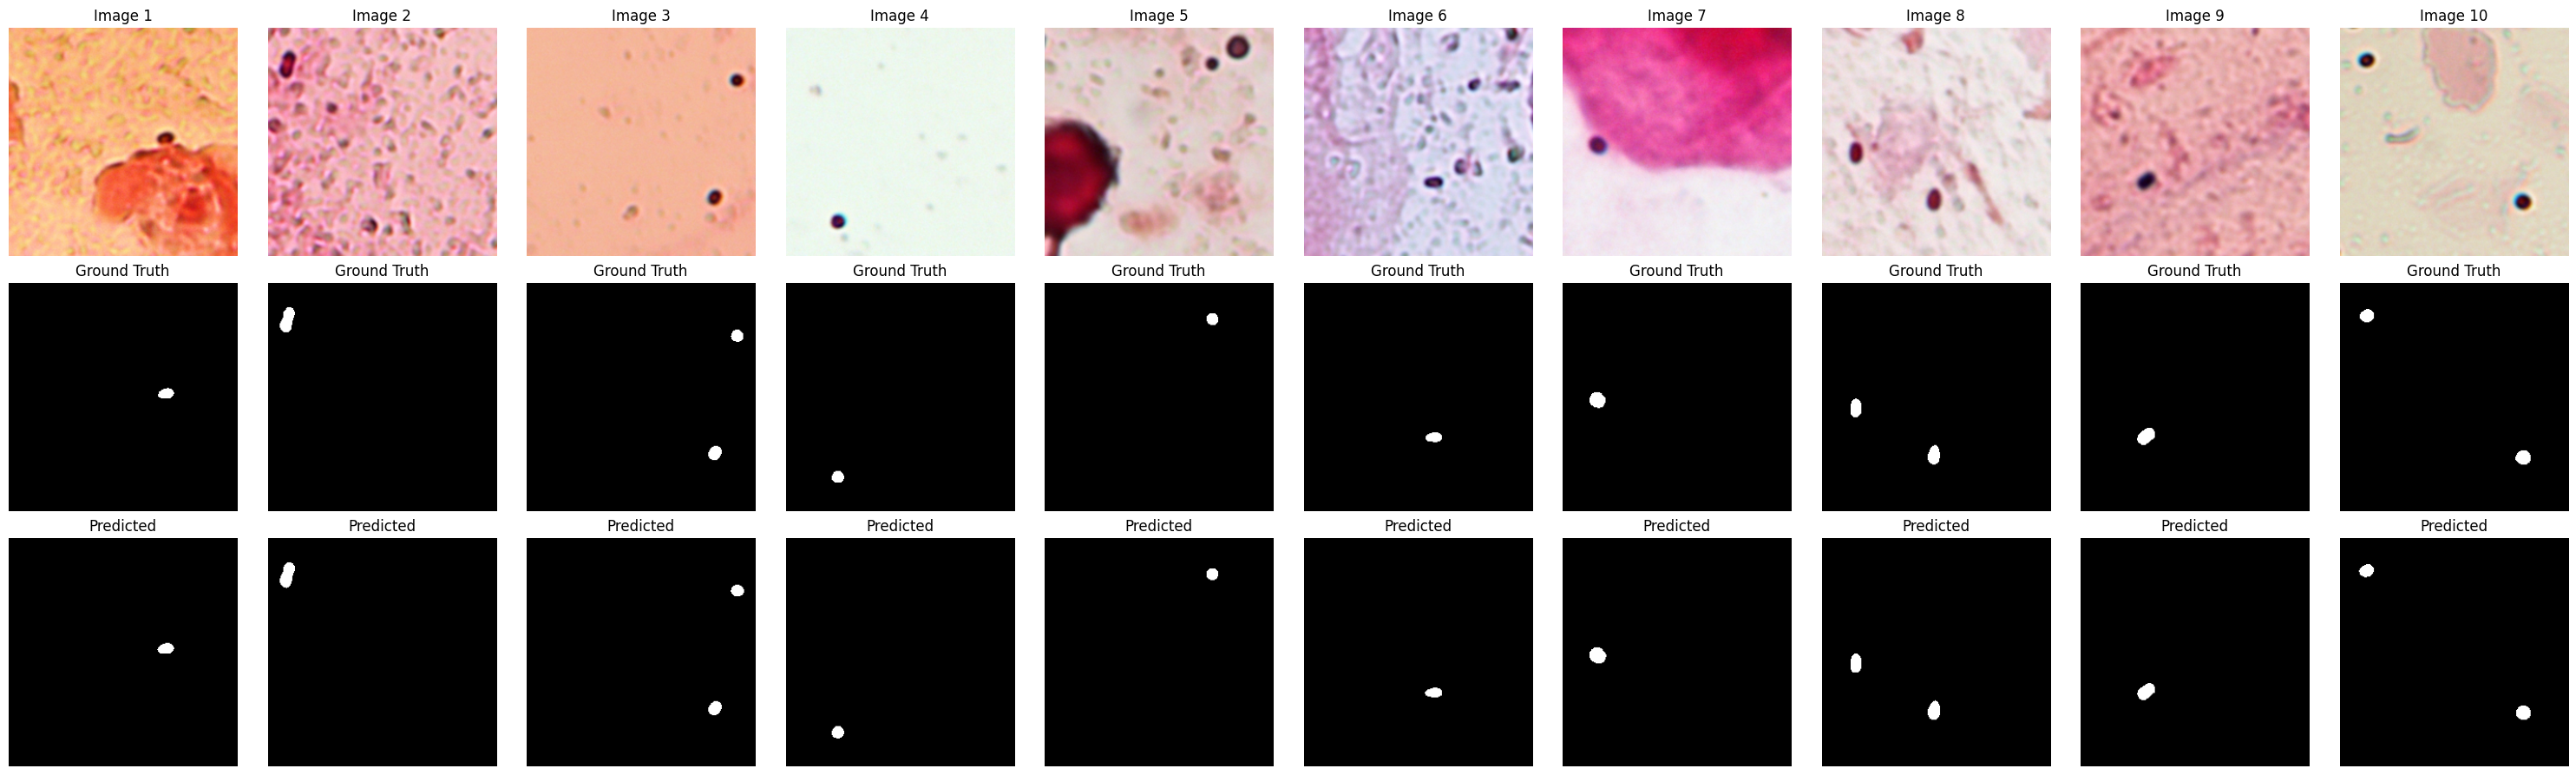

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

results = []

def compute_iou(pred, target, smooth=1e-6):
    intersection = ((pred == 1) & (target == 1)).sum().item()
    union = ((pred == 1) | (target == 1)).sum().item()
    return (intersection + smooth) / (union + smooth)

with torch.no_grad():
    for i in range(len(val_dataset)):
        image, mask = val_dataset[i]  # (C,H,W), (H,W)
        input_tensor = image.unsqueeze(0).to(device)

        output = model(input_tensor)

        if output.shape[1] > 1:  # multi-class
            preds = torch.argmax(output, dim=1).squeeze().cpu().numpy()
        else:  # binary
            preds = (torch.sigmoid(output) > 0.5).long().squeeze().cpu().numpy()

        gt_np = mask.cpu().numpy()

        iou = compute_iou(torch.tensor(preds), mask)

        img_np = image.permute(1, 2, 0).cpu().numpy()
        results.append((iou, img_np, gt_np, preds))

results = sorted(results, key=lambda x: x[0], reverse=True)
results = results[:min(100, len(results))]
results = random.sample(results, min(10, len(results)))

# === Plotting ===
fig, axes = plt.subplots(3, len(results), figsize=(len(results) * 3, 3 * 3))

for col, (iou, img, gt, pred) in enumerate(results):
    img_disp = (img - img.min()) / (img.max() - img.min() + 1e-8)

    axes[0, col].imshow(img_disp)
    axes[0, col].set_title(f"Image {col+1}", fontsize=12)

    axes[1, col].imshow(gt, cmap="gray")
    axes[1, col].set_title("Ground Truth", fontsize=12)

    axes[2, col].imshow(pred, cmap="gray")
    axes[2, col].set_title("Predicted", fontsize=12)

    for row in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("Prediction.png", dpi=1200)
plt.show()